# Practical 15: Transfer Learning Strategies: *Fine‑Tuning* vs. *Freezing the Backbone*


**Prerequisites:** Practical 4 (Transfer Learning) and Practicals 7–14 (Model Families)  

**Goal:** Understand two common transfer-learning strategies and *implement the "freeze the backbone, train only the classifier" approach* across multiple CNN families, then compare their performance.

> **Connection to previous practical:** In earlier practicals we **fine‑tuned** pre‑trained networks (we updated many or all weights). In this practical, because our dataset contains **natural images similar to ImageNet**, we will **freeze the backbone** (feature extractor) and **train only the final classifier**. This is often faster, needs fewer parameters to learn, and works well when the target data is close to ImageNet.



## 1) Concept: Two Transfer‑Learning Approaches

### A) Fine‑tuning (used earlier)
- **What you do:** Start from an ImageNet pre‑trained model and **allow many layers to update** during training.  
- **When to use:** Your dataset **looks different** from ImageNet (e.g., medical images, satellite data) or you have **enough data** to safely update many parameters.
- **Pros:** Often **higher accuracy** when enough data; can learn **task‑specific features**.
- **Cons:** **Slower**, more memory, and higher risk of **overfitting** with small datasets.

### B) Freeze the backbone, train only the classifier (**used here**)
- **What you do:** **Freeze** all convolutional layers (feature extractor) and **train only the last classifier layer**.  
- **When to use:** Your dataset is **similar to ImageNet** (natural objects, scenes) and/or you have **limited data or compute**.
- **Pros:** **Fast**, needs few parameters, usually stable.
- **Cons:** May be **less flexible** if your data is very different from ImageNet.

> **Key idea:** ImageNet pre‑trained features are like a strong “universal” visual vocabulary for natural images. If your new task is close enough, you can just learn a *small translator* (the classifier) on top.



## 2) What we’ll build

1. **Load a natural‑image dataset** (similar to ImageNet) using `torchvision.datasets.ImageFolder` (expected folder structure: `train/`, `val/`, `test/`).  
2. **Transform & normalize** images using the standard ImageNet settings.  
3. **Create a model zoo** (AlexNet, VGG16, GoogLeNet, SqueezeNet, ResNet18, MobileNetV2, DenseNet121, EfficientNet‑B0).  
4. For **each model**:  
   - Load ImageNet weights.  
   - **Freeze the backbone** and **replace the classifier head** with a new one that outputs `num_classes`.  
   - Train **only the classifier** for a few epochs.  
5. **Track training/validation curves** (loss & accuracy) and **plot** them.  
6. **Evaluate on the test set** and compare models in a tidy table and bar plots.  
7. **Pick one random test image** and show each model’s prediction vs. the true label (with confidence).



### **Dataset:**

Download the **flowers dataset** from my Google Drive: [Flowers Dataset Link](https://drive.google.com/file/d/1Oaghg3cBXOD88LAfa5pWXzuHtiJ93o7O/view?usp=sharing)
```
DATA_DIR/
  train/
    class_0/  image1.jpg ...
    class_1/  ...
    ...
  val/         
    class_0/  ...
  test/
    class_0/  ...
    class_1/  ...
```



## 3) Setup


In [ ]:

# === Imports & setup ===
import os, random, time, copy, math
import numpy as np
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

print('PyTorch version:', torch.__version__)
print('Torchvision version:', models.__version__ if hasattr(models,'__version__') else 'unknown')

# Reproducibility
seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


PyTorch version: 2.5.1
Torchvision version: unknown


device(type='cuda')

In [ ]:

# === Configuration (EDIT THESE PATHS/EPOCHS IF NEEDED) ===

# Root folder of your dataset (ImageFolder structure)
DATA_DIR = 'flowers'     # <-- change if needed

# Training settings
BATCH_SIZE = 100
NUM_WORKERS = 1
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 0.0

# If your dataset has no 'val' folder, we split from 'train' with this ratio.
#VAL_SPLIT = 0.2

# Which models to run (feel free to add/remove)
MODEL_NAMES = [
    'alexnet',
    'vgg16',
    'googlenet',
    'squeezenet1_0',
    'resnet18',
    'mobilenet_v2',
    'densenet121',
    'efficientnet_b0',
]


In [ ]:

# === Data transforms (ImageNet standard) ===
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

input_size = 224  # common input size for all chosen models

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [ ]:

# === Load datasets with ImageFolder ===

data_dir = Path(DATA_DIR)
assert data_dir.exists(), f"DATA_DIR does not exist: {data_dir}"

train_dir = data_dir / 'train'
test_dir  = data_dir / 'test'
val_dir   = data_dir / 'val'

assert train_dir.exists() and test_dir.exists(), "Expected 'train/' and 'test/' subfolders inside DATA_DIR."

dataset_train_full = datasets.ImageFolder(train_dir, transform=train_tfms)
class_names = dataset_train_full.classes
num_classes = len(class_names)
print('Classes:', class_names)

# If val/ exists use it; else split from train
if val_dir.exists():
    dataset_val = datasets.ImageFolder(val_dir, transform=eval_tfms)
else:
    n_total = len(dataset_train_full)
    n_val = int(VAL_SPLIT * n_total)
    n_train = n_total - n_val
    dataset_train_full = datasets.ImageFolder(train_dir, transform=train_tfms)  # reload to keep same transform
    dataset_train, dataset_val = random_split(dataset_train_full, [n_train, n_val], generator=torch.Generator().manual_seed(seed))
    # Wrap val subset with eval transforms
    dataset_val.dataset.transform = eval_tfms
    print(f"No 'val/' folder found; split train into {n_train} train and {n_val} val samples.")
    # For consistency, name train set
    dataset_train_full = dataset_train  # will use this as 'dataset_train' below

# If val/ existed, keep original train set
if val_dir.exists():
    dataset_train = datasets.ImageFolder(train_dir, transform=train_tfms)

dataset_test = datasets.ImageFolder(test_dir, transform=eval_tfms)

# DataLoaders
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
loader_test  = DataLoader(dataset_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

len(dataset_train), len(dataset_val), len(dataset_test)


Classes: ['Lilly', 'Lotus', 'Orchid', 'Sunflower', 'Tulip']


(4008, 500, 500)

In [ ]:

# === Helper functions ===
criterion_aux  = nn.CrossEntropyLoss()
def accuracy_from_logits(logits, y):
    preds = torch.argmax(logits, dim=1)
    return (preds == y).float().mean().item()

def eval_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    n = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            running_loss += loss.item() * x.size(0)
            running_correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)
    return running_loss / n, running_correct / n

def train_one_model(name, model, train_loader, val_loader, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Only train parameters that require grad (we'll set this when we replace heads)
    optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=weight_decay)
    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    best_wts = copy.deepcopy(model.state_dict())
    best_val_acc = -1

    for epoch in range(1, epochs+1):
        model.train()
        running_loss = 0.0
        running_correct = 0
        n = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            # GoogLeNet returns either a Tensor or a tuple with aux outputs (during train)
            if isinstance(out, tuple):
              main_logits, aux2_logits, aux1_logits = out  # torchvision order: main, aux2, aux1
              loss = criterion(main_logits, y) \
                 + 0.3 * criterion_aux(aux1_logits, y) \
                 + 0.3 * criterion_aux(aux2_logits, y)
              preds = main_logits.argmax(1)
            else:
              loss = criterion(out, y)
              preds = out.argmax(1)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            if isinstance(out, tuple):
                running_correct += (preds == y).sum().item()
            else:
                running_correct += (out.argmax(1) == y).sum().item()
            n += x.size(0)

        train_loss = running_loss / n
        train_acc = running_correct / n

        val_loss, val_acc = eval_model(model, val_loader, criterion)

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_wts = copy.deepcopy(model.state_dict())

        print(f"[{name}] Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} acc={train_acc:.3f} | val_loss={val_loss:.4f} acc={val_acc:.3f}")

    model.load_state_dict(best_wts)
    return model, history

def plot_histories(histories, key, title):
    plt.figure(figsize=(8,5))
    for name, hist in histories.items():
        plt.plot(hist['epoch'], hist[key], label=name)
    plt.xlabel('Epoch')
    plt.ylabel(key.replace('_',' ').title())
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def denormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    # img_tensor: CxHxW
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    return img_tensor * std + mean

def predict_one(model, img_tensor):
    model.eval()
    with torch.no_grad():
        logits = model(img_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1).squeeze(0).cpu()
        conf, pred = probs.max(0)
    return pred.item(), conf.item(), probs


In [ ]:

# === Model zoo: build with ImageNet weights; freeze backbone; replace classifier ===

def build_model(name, num_classes, freeze_backbone=True, pretrained=True):
    name = name.lower()
    # Backward-compatible 'pretrained' flag
    kwargs = {'pretrained': pretrained}

    if name == 'alexnet':
        m = models.alexnet(**kwargs)
        in_feat = m.classifier[-1].in_features
        m.classifier[-1] = nn.Linear(in_feat, num_classes)
    elif name == 'vgg16':
        m = models.vgg16(**kwargs)
        in_feat = m.classifier[-1].in_features
        m.classifier[-1] = nn.Linear(in_feat, num_classes)
    elif name == 'googlenet':
        # Disable aux logits for simplicity
        try:
            m = models.googlenet(aux_logits=True, **kwargs)
        except TypeError:
            # older torchvision might not accept aux_logits in **kwargs
            m = models.googlenet(pretrained=pretrained, aux_logits=True)
        in_feat = m.fc.in_features
        m.fc = nn.Linear(in_feat, num_classes)
    elif name == 'squeezenet1_0':
        m = models.squeezenet1_0(**kwargs)
        # Replace final conv classifier
        m.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
        m.num_classes = num_classes
    elif name == 'resnet18':
        m = models.resnet18(**kwargs)
        in_feat = m.fc.in_features
        m.fc = nn.Linear(in_feat, num_classes)
    elif name == 'mobilenet_v2':
        m = models.mobilenet_v2(**kwargs)
        # last layer is usually classifier[-1]
        in_feat = m.classifier[-1].in_features
        m.classifier[-1] = nn.Linear(in_feat, num_classes)
    elif name == 'densenet121':
        m = models.densenet121(**kwargs)
        in_feat = m.classifier.in_features
        m.classifier = nn.Linear(in_feat, num_classes)
    elif name == 'efficientnet_b0':
        try:
            m = models.efficientnet_b0(**kwargs)
        except TypeError:
            # older versions only accept pretrained
            m = models.efficientnet_b0(pretrained=pretrained)
        # classifier[1] is final linear in many versions
        if isinstance(m.classifier, nn.Sequential):
            # find last Linear
            lin_idx = None
            for i in reversed(range(len(m.classifier))):
                if isinstance(m.classifier[i], nn.Linear):
                    lin_idx = i; break
            if lin_idx is None:
                raise RuntimeError("Could not locate Linear layer in EfficientNet classifier.")
            in_feat = m.classifier[lin_idx].in_features
            m.classifier[lin_idx] = nn.Linear(in_feat, num_classes)
        else:
            # fallback
            in_feat = m.classifier.in_features
            m.classifier = nn.Linear(in_feat, num_classes)
    else:
        raise ValueError(f"Unknown model name: {name}")

    if freeze_backbone:
        for p in m.parameters():
            p.requires_grad = False
        # Unfreeze classifier head we just replaced
        # Identify typical head attributes
        head_params = []
        for attr in ['fc', 'classifier']:
            if hasattr(m, attr):
                head = getattr(m, attr)
                for p in head.parameters():
                    p.requires_grad = True
                head_params += list(head.parameters())
        # Special case: SqueezeNet's conv head is inside classifier[1] (already covered by 'classifier')

    return m

# Quick sanity check: build one of each
for n in ['alexnet','vgg16','googlenet','squeezenet1_0','resnet18','mobilenet_v2','densenet121','efficientnet_b0']:
    _ = build_model(n, num_classes)
print("Model builders OK.")


c:\ProgramData\Anaconda3\envs\torch25\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\ProgramData\Anaconda3\envs\torch25\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\ProgramData\Anaconda3\envs\torch25\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.

Model builders OK.


c:\ProgramData\Anaconda3\envs\torch25\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:

# === Train all models (freeze backbone, train classifier only) ===

trained_models = {}
histories = {}

for name in MODEL_NAMES:
    print('\n' + '='*80)
    print(f"Training model: {name}")
    print('='*80)
    model = build_model(name, num_classes, freeze_backbone=True, pretrained=True)
    model, history = train_one_model(name, model, loader_train, loader_val, epochs=EPOCHS, lr=LR, weight_decay=WEIGHT_DECAY)
    trained_models[name] = model
    histories[name] = history

print("\nDone training all models.")



Training model: alexnet
[alexnet] Epoch 01/20 | train_loss=1.0089 acc=0.653 | val_loss=0.5725 acc=0.790
[alexnet] Epoch 02/20 | train_loss=0.6505 acc=0.760 | val_loss=0.3895 acc=0.862
[alexnet] Epoch 03/20 | train_loss=0.5994 acc=0.783 | val_loss=0.3911 acc=0.864
[alexnet] Epoch 04/20 | train_loss=0.5509 acc=0.798 | val_loss=0.3610 acc=0.864
[alexnet] Epoch 05/20 | train_loss=0.5338 acc=0.805 | val_loss=0.3117 acc=0.886
[alexnet] Epoch 06/20 | train_loss=0.4979 acc=0.820 | val_loss=0.3140 acc=0.900
[alexnet] Epoch 07/20 | train_loss=0.4965 acc=0.817 | val_loss=0.2757 acc=0.896
[alexnet] Epoch 08/20 | train_loss=0.4850 acc=0.827 | val_loss=0.2577 acc=0.912
[alexnet] Epoch 09/20 | train_loss=0.4395 acc=0.843 | val_loss=0.2740 acc=0.898
[alexnet] Epoch 10/20 | train_loss=0.4651 acc=0.826 | val_loss=0.2727 acc=0.904
[alexnet] Epoch 11/20 | train_loss=0.4462 acc=0.835 | val_loss=0.2833 acc=0.898
[alexnet] Epoch 12/20 | train_loss=0.4538 acc=0.836 | val_loss=0.2547 acc=0.906
[alexnet] Epoch

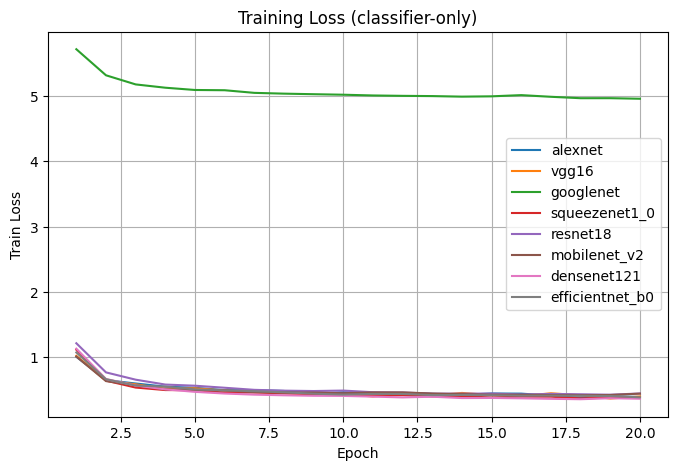

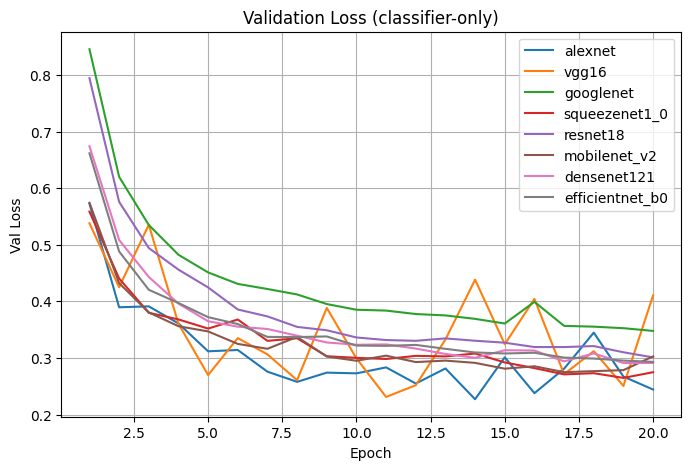

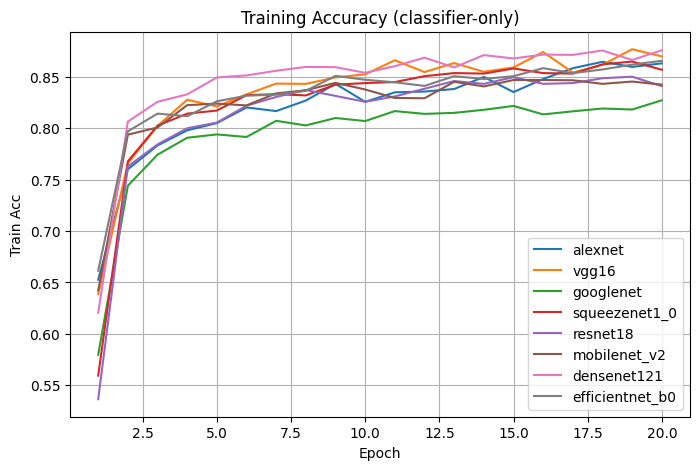

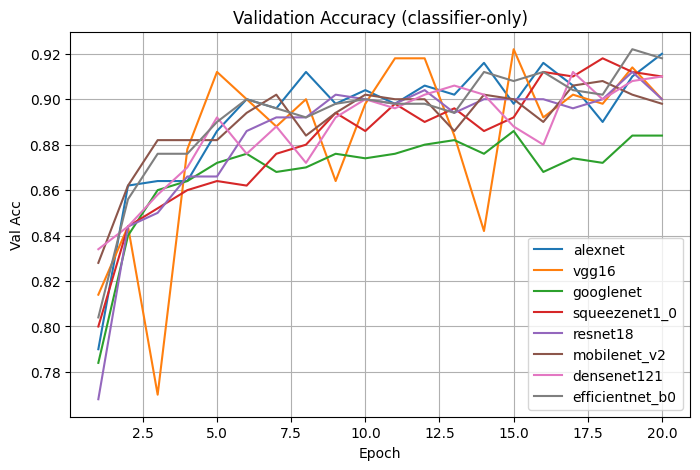

In [ ]:

# === Compare curves ===
plot_histories(histories, key='train_loss', title='Training Loss (classifier-only)')
plot_histories(histories, key='val_loss',   title='Validation Loss (classifier-only)')
plot_histories(histories, key='train_acc',  title='Training Accuracy (classifier-only)')
plot_histories(histories, key='val_acc',    title='Validation Accuracy (classifier-only)')


In [ ]:

# === Test-set evaluation ===
criterion = nn.CrossEntropyLoss()
rows = []
for name, model in trained_models.items():
    test_loss, test_acc = eval_model(model, loader_test, criterion)
    rows.append({'model': name, 'test_loss': test_loss, 'test_acc': test_acc})

results_df = pd.DataFrame(rows).sort_values(by='test_acc', ascending=False).reset_index(drop=True)
results_df


,model,test_loss,test_acc
0,alexnet,0.248967,0.906
1,vgg16,0.309310,0.906
2,efficientnet_b0,0.343299,0.884
3,mobilenet_v2,0.356249,0.884
4,googlenet,0.396266,0.880
5,resnet18,0.366816,0.878
6,densenet121,0.316407,0.874
7,squeezenet1_0,0.353948,0.870


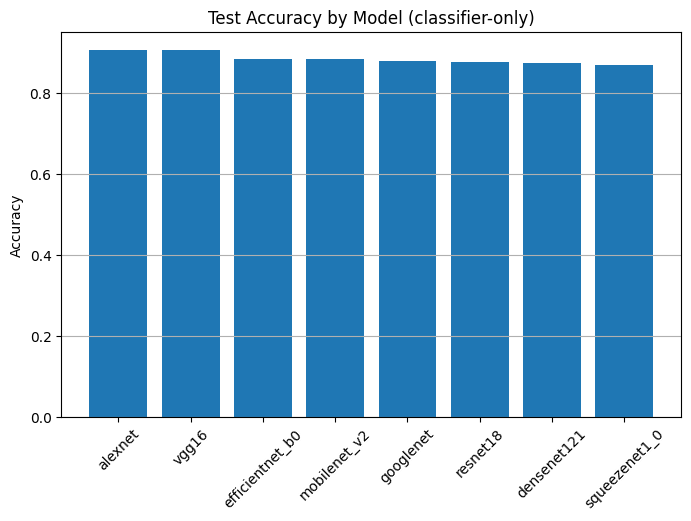

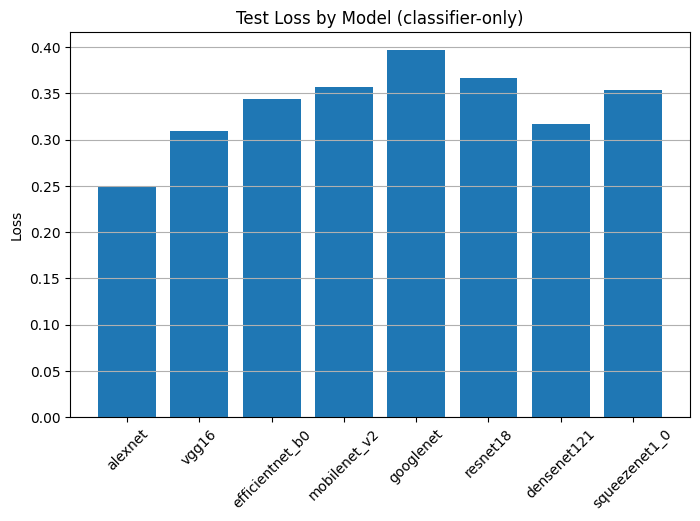

Saved: C:\Users\dell\Desktop\CV\notebooks\results_classifier_only.csv


In [ ]:

# Bar plots for test accuracy and loss
plt.figure(figsize=(8,5))
plt.bar(results_df['model'], results_df['test_acc'])
plt.title('Test Accuracy by Model (classifier-only)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

plt.figure(figsize=(8,5))
plt.bar(results_df['model'], results_df['test_loss'])
plt.title('Test Loss by Model (classifier-only)')
plt.ylabel('Loss')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()

# Save results
out_path = Path('results_classifier_only.csv')
results_df.to_csv(out_path, index=False)
print('Saved:', out_path.resolve())


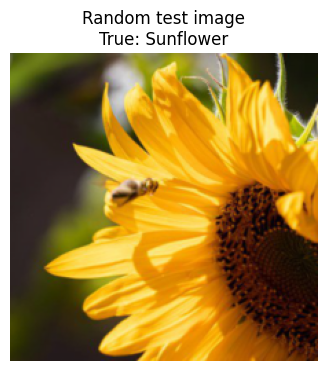

,model,pred_label,confidence
0,vgg16,Sunflower,0.999995
1,alexnet,Sunflower,0.999925
2,squeezenet1_0,Sunflower,0.998849
3,efficientnet_b0,Sunflower,0.998749
4,mobilenet_v2,Sunflower,0.997259
5,resnet18,Sunflower,0.978021
6,densenet121,Sunflower,0.973696
7,googlenet,Sunflower,0.932815


In [ ]:

# === Random test image: show all model predictions vs true label ===

# Access the underlying ImageFolder to fetch original path for display
test_img_path, true_label_idx = dataset_test.samples[random.randrange(len(dataset_test))]
true_label = class_names[true_label_idx]

# Load with eval transforms for model input
pil_img = Image.open(test_img_path).convert('RGB')
img_tensor = eval_tfms(pil_img)

# For display: denormalize
disp = denormalize(img_tensor).clamp(0,1).permute(1,2,0).numpy()

plt.figure(figsize=(4,4))
plt.imshow(disp)
plt.axis('off')
plt.title(f"Random test image\nTrue: {true_label}")
plt.show()

# Collect predictions
pred_rows = []
for name, model in trained_models.items():
    pred_idx, conf, probs = predict_one(model, img_tensor)
    pred_label = class_names[pred_idx]
    pred_rows.append({'model': name, 'pred_label': pred_label, 'confidence': conf})

pred_df = pd.DataFrame(pred_rows).sort_values(by='confidence', ascending=False).reset_index(drop=True)
pred_df



## 4) Summary

- **Earlier**: You practiced **fine‑tuning** (updating many weights). This is powerful but heavier.  
- **Today**: You **froze the backbone** and trained only the classifier. This is **fast and effective** when your dataset is **similar to ImageNet** (natural images).  
- **Result**: Different backbones give different accuracies even with the same strategy—try more epochs or a small unfreeze (e.g., last block) if you need a boost.  
- **Next**: We’ll discuss **hyperparameter tuning** and **light unfreezing** strategies to push accuracy while controlling training time.



> **Optional extension (if time):** Try unfreezing the **last block** (e.g., `layer4` in ResNet) and train for a few more epochs with a **smaller LR** (e.g., `1e-4`). This blends the two strategies and often gives a small accuracy boost.


## Next Practical: **Vision Transformer (ViT)**
In the next notebook, we’ll switch from convolutional blocks to **self‑attention** and see how a ViT handles the same **flowers** dataset.

---
📝 This practical was designed to give you hands-on with Transfer Learning: load an ImageNet-pretrained backbone, compare freeze vs. fine-tune.